# SHOW ME your WORK 💪

# Problem statement
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient

# Data Collection
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score

In [5]:
# read the data
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning

In [6]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [7]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [8]:
df = df.drop('CustomerID', axis=1)

In [11]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [13]:
cat_cols = df.select_dtypes(include=['object','str']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

## Feature Engineering & Encoding

In [15]:
df_enc = pd.get_dummies(df, drop_first=True)

In [16]:
X = df_enc.drop('ProdTaken',axis=1) # assume 'ProdTaken' target
y = df_enc['ProdTaken']

In [18]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.2, random_state=42)

#### Build a classification model using support vector machine. Use standalone model as well as Bagging model and check if you see any difference in the performance.

In [20]:
svm = SVC(random_state=42)
svm.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
svm_pred = svm.predict(X_test)
test_accuracy = accuracy_score(y_test, svm_pred)
print('The test accuracy is', test_accuracy)

The test accuracy is 0.8609406952965235


In [37]:
bag = BaggingClassifier(
    estimator=SVC(random_state=42),
    n_estimators= 20 ,
    random_state=42)
bag.fit(X_train,y_train)

,estimator,SVC(random_state=42)
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [38]:
bag_pred = bag.predict(X_test)
test_accuracy = accuracy_score(y_test, bag_pred)
print('The test accuracy is', test_accuracy)

The test accuracy is 0.8660531697341514


#### Now use decision tree classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [33]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
tree_pred = tree.predict(X_test)
test_accuracy = accuracy_score(y_test, tree_pred)
print('The test accuracy is', test_accuracy)

The test accuracy is 0.9100204498977505


In [35]:
bag_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators= 100 ,
    random_state=42)
bag_tree.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [36]:
bag_tree_pred = bag_tree.predict(X_test)
test_accuracy = accuracy_score(y_test, bag_tree_pred)
print('The test accuracy is', test_accuracy)

The test accuracy is 0.9366053169734151


#### then use random forest classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [45]:
forest = RandomForestClassifier(random_state=42 ,n_estimators=20)
forest.fit(X_train,y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
forest_pred = forest.predict(X_test)
test_accuracy = accuracy_score(y_test, forest_pred)
print('The test accuracy is', test_accuracy)

The test accuracy is 0.9069529652351738


In [48]:
bag_forest = BaggingClassifier(
    estimator=RandomForestClassifier(random_state=42),
    n_estimators= 10 ,
    random_state=42)
bag_forest.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [49]:
bag_forest_pred = bag_forest.predict(X_test)
test_accuracy = accuracy_score(y_test, bag_forest_pred)
print('The test accuracy is', test_accuracy)

The test accuracy is 0.8885480572597138


#### Comparing performance of them to figure out where it makes most sense to use bagging and why. What conditions bagging works the best.

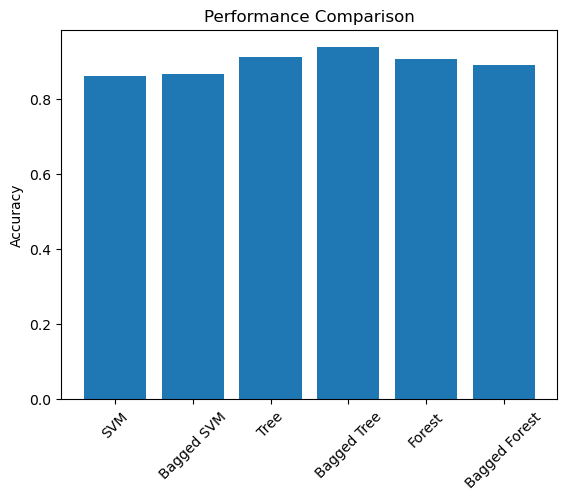

In [53]:
models = ['SVM', 'Bagged SVM', 'Tree', 'Bagged Tree', 'Forest', 'Bagged Forest']
accuracies = [
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, bag_pred),
    accuracy_score(y_test, tree_pred),
    accuracy_score(y_test, bag_tree_pred),
    accuracy_score(y_test, forest_pred),
    accuracy_score(y_test, bag_forest_pred)
]

plt.bar(models, accuracies)
plt.xticks(rotation=45)
plt.ylabel('Accuracy')
plt.title('Performance Comparison')
plt.show()